# Climate Pattern Detection with ClimateNet

Use the ClimateNet diagnostic model to detect atmospheric rivers, tropical cyclones, and frontal zones in AI weather forecast output.

**Extra install:** `uv add earth2studio --extra climatenet`

In [1]:
import os
from datetime import datetime

import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import earth2studio.run as run
from earth2studio.models.px import FCN
from earth2studio.models.dx import ClimateNet
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend

/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/jovyan/earth2studio-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


In [2]:
CONFIG = {
    # Choose a date with active weather (e.g., atmospheric rivers hitting US West Coast)
    "forecast_date": "2023-11-20",
    "nsteps": 10,
    "output_root": "outputs/climate_patterns",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

os.makedirs(CONFIG["output_root"], exist_ok=True)
print(f"Device: {CONFIG['device']}")

Device: cuda


## Run Forecast with ClimateNet

In [3]:
fcn_model = FCN.load_model(FCN.load_default_package())
climatenet_model = ClimateNet.load_model(ClimateNet.load_default_package())
gfs_data = GFS()

io = ZarrBackend(
    f"{CONFIG['output_root']}/fcn_climatenet.zarr",
    backend_kwargs={"overwrite": True},
)
io = run.diagnostic(
    [CONFIG["forecast_date"]], CONFIG["nsteps"],
    fcn_model, climatenet_model, gfs_data, io,
)
ds = xr.open_zarr(f"{CONFIG['output_root']}/fcn_climatenet.zarr")

print("Variables:", list(ds.data_vars))
print("Dimensions:", dict(ds.dims))

2026-04-06 23:15:16.095 | INFO     | earth2studio.run:diagnostic:198 - Running diagnostic workflow!
2026-04-06 23:15:16.095 | INFO     | earth2studio.run:diagnostic:205 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-06 23:15:17.134 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231120/00/atmos/gfs.t00z.pgrb2.0p25.f000 401425952-945109
2026-04-06 23:15:17.137 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231120/00/atmos/gfs.t00z.pgrb2.0p25.f000 152813274-757988
2026-04-06 23:15:17.138 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231120/00/atmos/gfs.t00z.pgrb2.0p25.f000 421142927-961749
2026-04-06 23:15:17.141 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231120/00/atmos/gfs.t00z.pgrb2.0p25.f000 337769627-837348
2026-04-06 23:15:17.142 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231120/00/atmos/gfs.t00z.pgrb2.0p25.f000 261817356-792470
2026-04-06 23:15:17.144 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 22.05it/s]


2026-04-06 23:15:18.403 | SUCCESS  | earth2studio.run:diagnostic:228 - Fetched data from GFS
2026-04-06 23:15:18.425 | INFO     | earth2studio.run:diagnostic:260 - Inference starting!



Running inference: 100%|██████████| 11/11 [00:04<00:00,  2.23it/s]

2026-04-06 23:15:23.352 | SUCCESS  | earth2studio.run:diagnostic:276 - 
Inference complete
Variables: ['climnet_tc', 'climnet_bg', 'climnet_ar']
Dimensions: {'time': 1, 'lead_time': 11, 'lat': 721, 'lon': 1440}


In [4]:
# Inspect ClimateNet output — typically provides class labels per grid cell
# Classes: 0 = background, 1 = tropical cyclone, 2 = atmospheric river
for var in ds.data_vars:
    shape = ds[var].shape
    print(f"  {var}: {shape}")

  climnet_tc: (1, 11, 721, 1440)
  climnet_bg: (1, 11, 721, 1440)
  climnet_ar: (1, 11, 721, 1440)


## Detected Weather Patterns

In [5]:
# ClimateNet class mapping
CLASSES = {0: "Background", 1: "Tropical Cyclone", 2: "Atmospheric River"}
CLASS_COLORS = {0: "white", 1: "red", 2: "blue"}

# Build a discrete colormap for the classes
cmap_classes = mcolors.ListedColormap(["white", "red", "blue"])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap_classes.N)

lats = ds["lat"].values
lons = ds["lon"].values

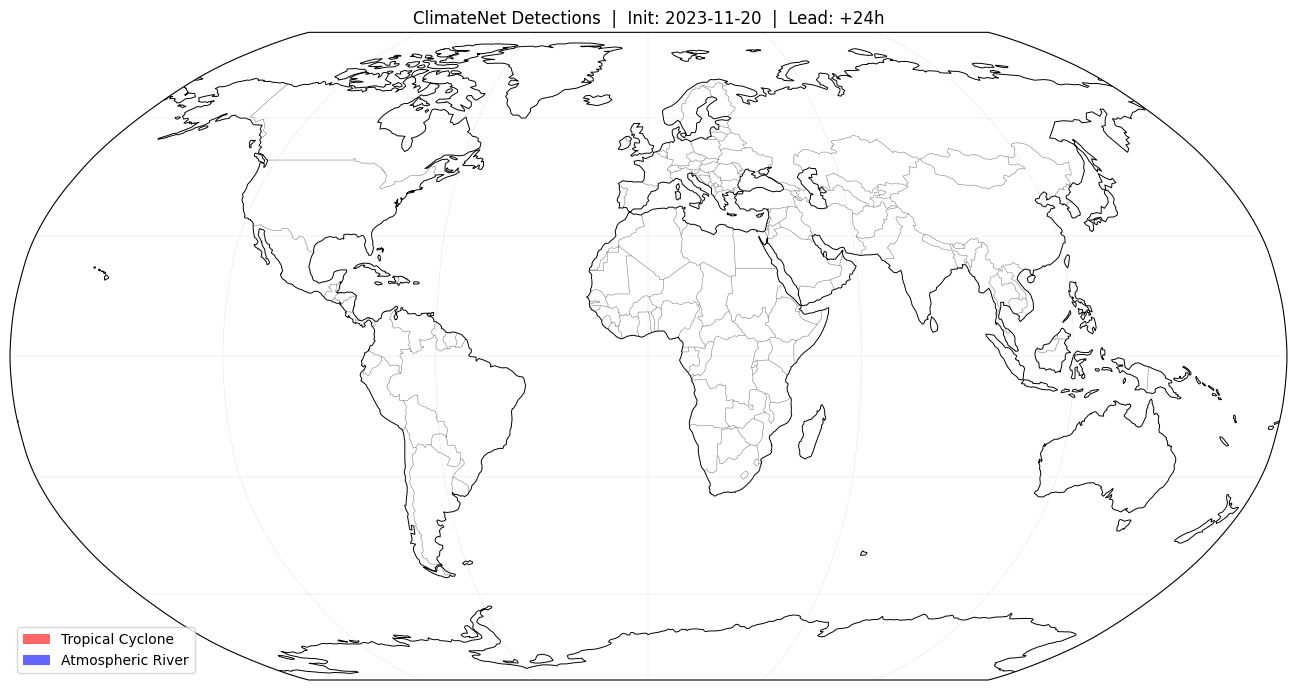

In [6]:
def plot_climate_features(ds, step, extent=None, save_path=None):
    """Overlay ClimateNet detections on a T2M background."""
    lead_hours = step * 6

    # Find the ClimateNet output variable
    climate_vars = [v for v in ds.data_vars if v not in ["t2m", "u10m", "v10m", "msl", "z500",
                    "tp", "u100m", "v100m", "sp", "tcwv"]]
    if not climate_vars:
        print("No ClimateNet output variable found.")
        return
    climate_var = climate_vars[0]

    labels = ds[climate_var].isel(time=0, lead_time=step).values

    # T2M background
    if "t2m" in ds.data_vars:
        t2m_c = ds["t2m"].isel(time=0, lead_time=step).values - 273.15
    else:
        t2m_c = None

    fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={"projection": ccrs.Robinson()})

    if t2m_c is not None:
        ax.pcolormesh(lons, lats, t2m_c, transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-40, vmax=40, shading="auto", alpha=0.4)

    # Overlay detected features
    ax.pcolormesh(lons, lats, labels, transform=ccrs.PlateCarree(),
                  cmap=cmap_classes, norm=norm, shading="auto", alpha=0.6)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.gridlines(linewidth=0.3, alpha=0.4)

    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="red", alpha=0.6, label="Tropical Cyclone"),
        Patch(facecolor="blue", alpha=0.6, label="Atmospheric River"),
    ]
    ax.legend(handles=legend_elements, loc="lower left", fontsize=10)

    ax.set_title(f"ClimateNet Detections  |  Init: {CONFIG['forecast_date']}  |  Lead: +{lead_hours}h")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# Global view at +24h
plot_climate_features(ds, step=4, save_path=f"{CONFIG['output_root']}/global_step04.png")

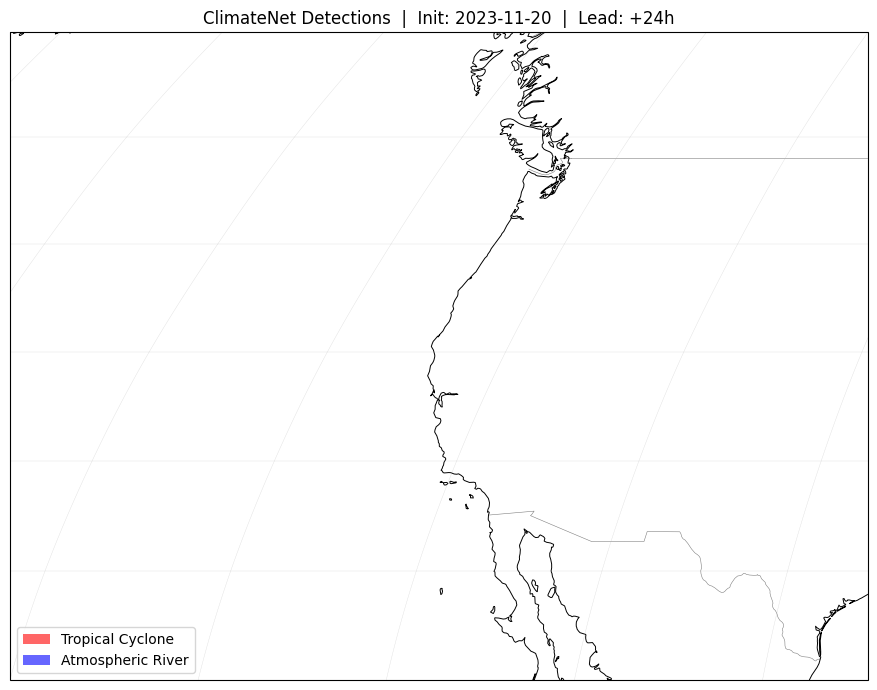

In [7]:
# US West Coast zoom — atmospheric river detail
plot_climate_features(
    ds, step=4,
    extent=[-140, -110, 25, 55],
    save_path=f"{CONFIG['output_root']}/west_coast_step04.png",
)

## Feature Propagation Over Time

In [ ]:
steps = [0, 4, 8, 10]
fig, axes = plt.subplots(2, 2, figsize=(18, 12), subplot_kw={"projection": ccrs.Robinson()})

climate_vars = [v for v in ds.data_vars if v not in ["t2m", "u10m", "v10m", "msl", "z500",
                "tp", "u100m", "v100m", "sp", "tcwv"]]
climate_var = climate_vars[0] if climate_vars else None

for ax, step in zip(axes.flat, steps):
    lead_hours = step * 6

    if "t2m" in ds.data_vars:
        t2m_c = ds["t2m"].isel(time=0, lead_time=step).values - 273.15
        ax.pcolormesh(lons, lats, t2m_c, transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-40, vmax=40, shading="auto", alpha=0.4)

    if climate_var:
        labels = ds[climate_var].isel(time=0, lead_time=step).values
        ax.pcolormesh(lons, lats, labels, transform=ccrs.PlateCarree(),
                      cmap=cmap_classes, norm=norm, shading="auto", alpha=0.6)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.gridlines(linewidth=0.3, alpha=0.3)
    ax.set_title(f"+{lead_hours}h", fontsize=12)

fig.suptitle(f"ClimateNet Feature Evolution  |  Init: {CONFIG['forecast_date']}", fontsize=14, y=0.98)
plt.savefig(f"{CONFIG['output_root']}/time_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Statistics

In [ ]:
if climate_var:
    counts = {"Tropical Cyclone": [], "Atmospheric River": []}
    all_hours = []
    for s in range(CONFIG["nsteps"] + 1):
        labels = ds[climate_var].isel(time=0, lead_time=s).values
        counts["Tropical Cyclone"].append(np.sum(labels == 1))
        counts["Atmospheric River"].append(np.sum(labels == 2))
        all_hours.append(s * 6)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(all_hours, counts["Tropical Cyclone"], marker="s", color="red", label="TC grid cells")
    ax.plot(all_hours, counts["Atmospheric River"], marker="o", color="blue", label="AR grid cells")
    ax.set_xlabel("Lead Time (hours)")
    ax.set_ylabel("Number of Grid Cells Detected")
    ax.set_title(f"Detected Feature Coverage Over Forecast  |  Init: {CONFIG['forecast_date']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_root']}/feature_counts.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("ClimateNet output variable not found — inspect ds.data_vars above.")